# Visualizing and the merged datasets to draw conclusions before model training

In [1]:
%%capture
import matplotlib.pyplot as plt
%pip install seaborn
import seaborn as sns
import pandas as pd
%pip install wordcloud
from wordcloud import WordCloud

In [2]:
data = pd.read_csv('data/extra_and_merged_data.csv')  # Assume csvread is a function to read CSV files
data.head()

,date,summary,volume,pct_change,target,pct_change_lag1,volume_lag1,volume_5d_avg
0,2003-02-20,aba decides community broadcasting licence act...,1.194100e+09,-0.009502,1.0,NaN,NaN,NaN
1,2003-02-21,accc timid petrol price investigation action w...,1.398200e+09,0.013224,0.0,-0.009502,1.194100e+09,NaN
2,2003-02-24,86 confirmed dead u nightclub fire act tourist...,1.229200e+09,-0.018381,1.0,0.013224,1.398200e+09,NaN
3,2003-02-25,4 million pay sacked ceo aid organisation disa...,1.483700e+09,0.007194,0.0,-0.018381,1.229200e+09,NaN
4,2003-02-26,ab defends nt population shrinking claim acb r...,1.374400e+09,-0.013141,1.0,0.007194,1.483700e+09,1.335920e+09


Target Distribution

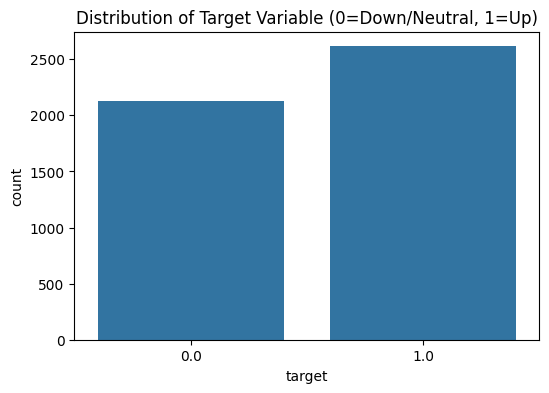

In [3]:
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=data)
plt.title('Distribution of Target Variable (0=Down/Neutral, 1=Up)')
plt.show()

This makes sense because the S&p 500 is on the increase year to year because of companies reinvesting, increase in productivity, population growth and GDP growth over time. GDP in 2017 was 19 trillion and GDP in 2020 was 21 trillion.

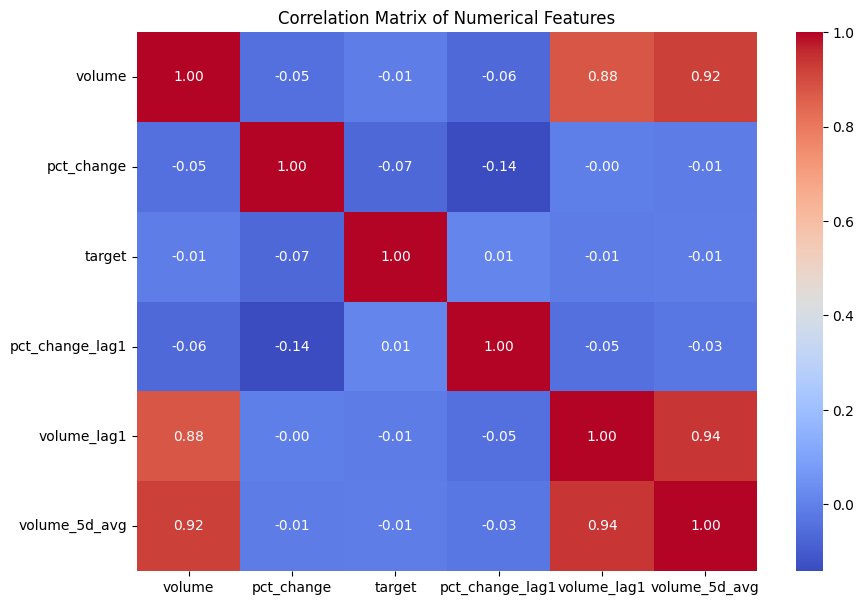

In [5]:

numeric_cols = ['volume', 'pct_change', 'target',
                'pct_change_lag1', 'volume_lag1', 'volume_5d_avg']
plt.figure(figsize=(10, 7))
sns.heatmap(data[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

Good correlation between Volume 5 day average in todays volume meaning that the volumne carries out day to day. Meaning a high volume peak can lead to high volumes over the next 5 days

pct_change and pct_change_lag1 has negative correlation meaning that if today is up then tomorrow is most likely to be down and vise versa

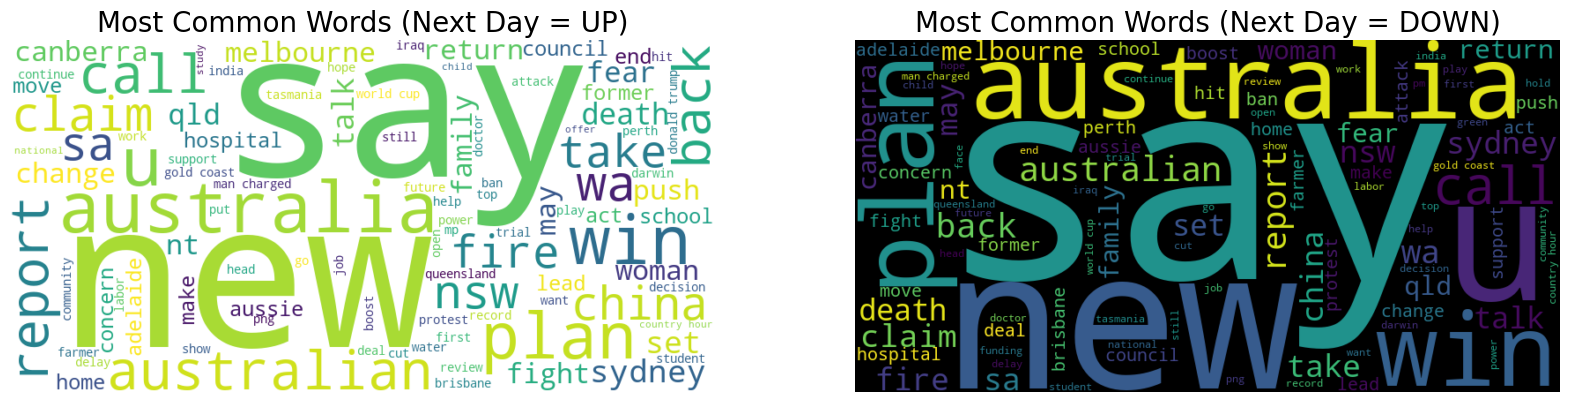

In [6]:
text_up = ' '.join(data[data['target']==1]['summary'])
text_down = ' '.join(data[data['target']==0]['summary'])

wordcloud_up = WordCloud(background_color='white', max_words=100, width=800, height=400).generate(text_up)
wordcloud_down = WordCloud(background_color='black', max_words=100, width=800, height=400).generate(text_down)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
ax1.imshow(wordcloud_up, interpolation='bilinear')
ax1.set_title('Most Common Words (Next Day = UP)', fontsize=20)
ax1.axis('off')
ax2.imshow(wordcloud_down, interpolation='bilinear')
ax2.set_title('Most Common Words (Next Day = DOWN)', fontsize=20)
ax2.axis('off')
plt.show()

In [7]:
from collections import Counter
import re

# function to tokenize and clean words
def tokenize(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)   # remove punctuation/numbers
    return text.split()

# get text for target UP and DOWN
text_up = ' '.join(data[data['target'] == 1]['summary'])
text_down = ' '.join(data[data['target'] == 0]['summary'])

# tokenize
words_up = tokenize(text_up)
words_down = tokenize(text_down)

# total word counts
total_up = len(words_up)
total_down = len(words_down)

# frequency counters
freq_up = Counter(words_up)
freq_down = Counter(words_down)

# convert to percentage (frequency / total)
percent_up = {word: (count / total_up) * 100 for word, count in freq_up.items()}
percent_down = {word: (count / total_down) * 100 for word, count in freq_down.items()}

# get top 10 by percent
top_up = sorted(percent_up.items(), key=lambda x: x[1], reverse=True)[:10]
top_down = sorted(percent_down.items(), key=lambda x: x[1], reverse=True)[:10]

# print results
print("\n🔺 Top 10 Words for Target = 1 (UP) — Percentage Usage:")
for w, p in top_up:
    print(f"{w}: {p:.3f}%")

print("\n🔻 Top 10 Words for Target = 0 (DOWN) — Percentage Usage:")
for w, p in top_down:
    print(f"{w}: {p:.3f}%")



🔺 Top 10 Words for Target = 1 (UP) — Percentage Usage:
over: 0.802%
police: 0.584%
new: 0.497%
man: 0.464%
say: 0.421%
up: 0.335%
u: 0.305%
australia: 0.297%
call: 0.288%
council: 0.284%

🔻 Top 10 Words for Target = 0 (DOWN) — Percentage Usage:
over: 0.796%
police: 0.583%
new: 0.491%
man: 0.469%
say: 0.426%
up: 0.337%
u: 0.300%
australia: 0.296%
plan: 0.288%
call: 0.287%


The trend is the word count is not very distinct but there are a couple of words that stick out like coronvirus which was shown in when stocks where on the down trend. But these words are very common when talking about finaices whether they are positive or negative